In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

In [3]:
import torch
import matplotlib.pyplot as plt
import obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import matplotlib.pyplot as plt

from eqnet.models.sb_model import PhaseNet

In [4]:
model = PhaseNet()
model.load_state_dict(torch.load("../models/model_99.pth", map_location=torch.device('cpu'))["model"])

<All keys matched successfully>

In [5]:
x = torch.rand((5, 3, 4096, 1))
output = model(x)
output.keys()

dict_keys(['phase', 'event_center', 'event_time', 'polarity'])

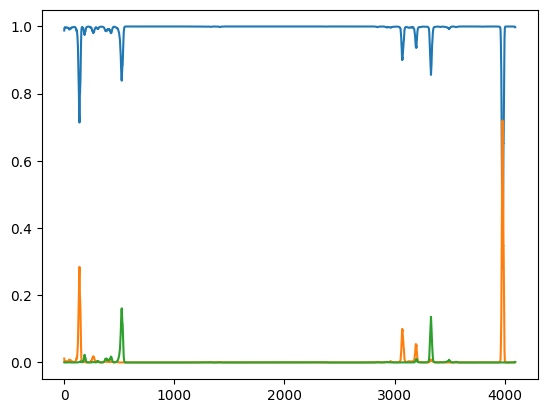

In [6]:
plt.plot(output["phase"][0, :, :, 0].T.detach().numpy())

In [7]:
client = Client("GFZ")

t = UTCDateTime("2007/01/02 05:48:50")
stream = client.get_waveforms(network="CX", station="PB01", location="*", channel="HH?", starttime=t-100, endtime=t+100)

In [8]:
ann = model.annotate(stream)
ann

6 Trace(s) in Stream:
CX.PB01..PhaseNet_N    | 2007-01-02T05:47:10.000000Z - 2007-01-02T05:50:30.000000Z | 100.0 Hz, 20001 samples
CX.PB01..PhaseNet_P    | 2007-01-02T05:47:10.000000Z - 2007-01-02T05:50:30.000000Z | 100.0 Hz, 20001 samples
CX.PB01..PhaseNet_S    | 2007-01-02T05:47:10.000000Z - 2007-01-02T05:50:30.000000Z | 100.0 Hz, 20001 samples
CX.PB01..PhaseNet_None | 2007-01-02T05:47:10.000000Z - 2007-01-02T05:50:30.000000Z | 100.0 Hz, 20001 samples
CX.PB01..PhaseNet_Up   | 2007-01-02T05:47:10.000000Z - 2007-01-02T05:50:30.000000Z | 100.0 Hz, 20001 samples
CX.PB01..PhaseNet_Down | 2007-01-02T05:47:10.000000Z - 2007-01-02T05:50:30.000000Z | 100.0 Hz, 20001 samples

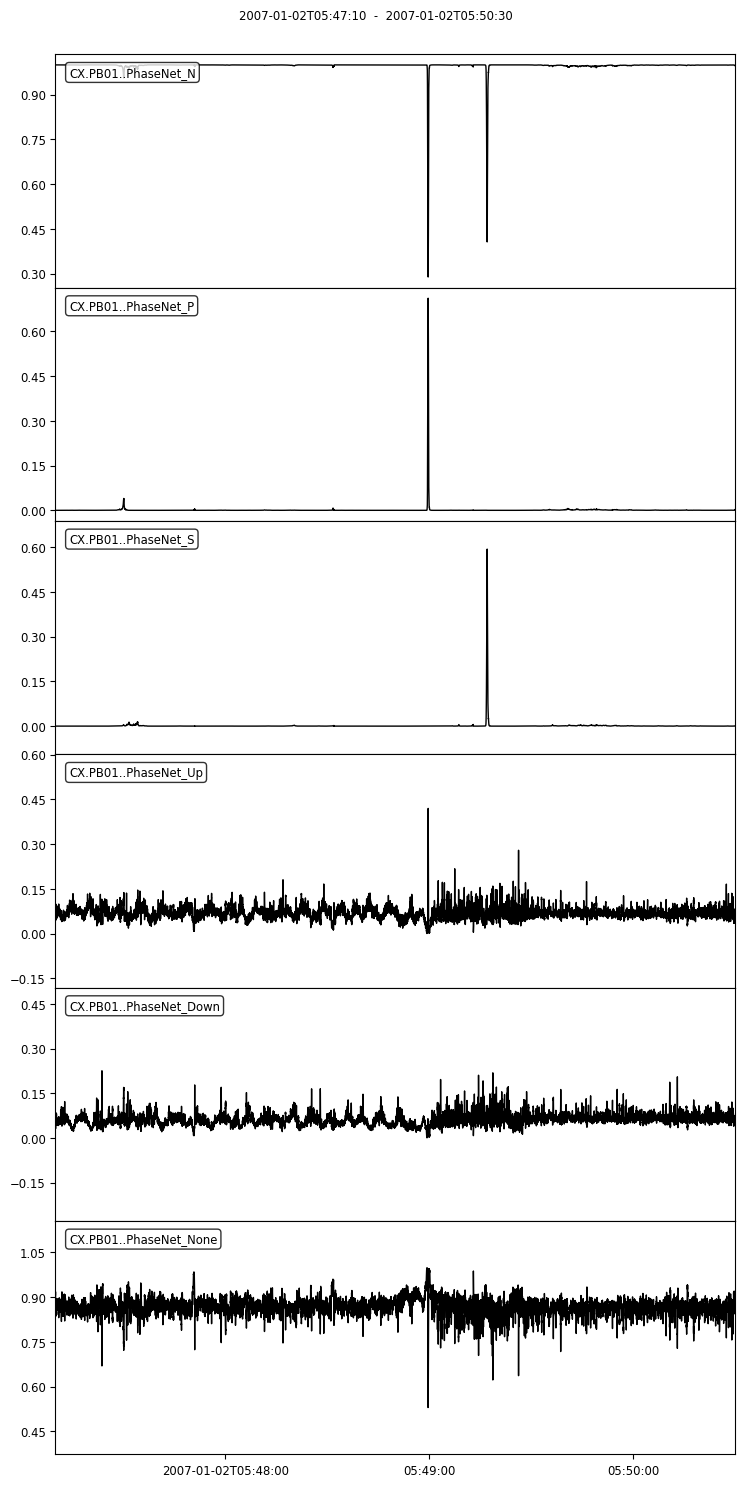

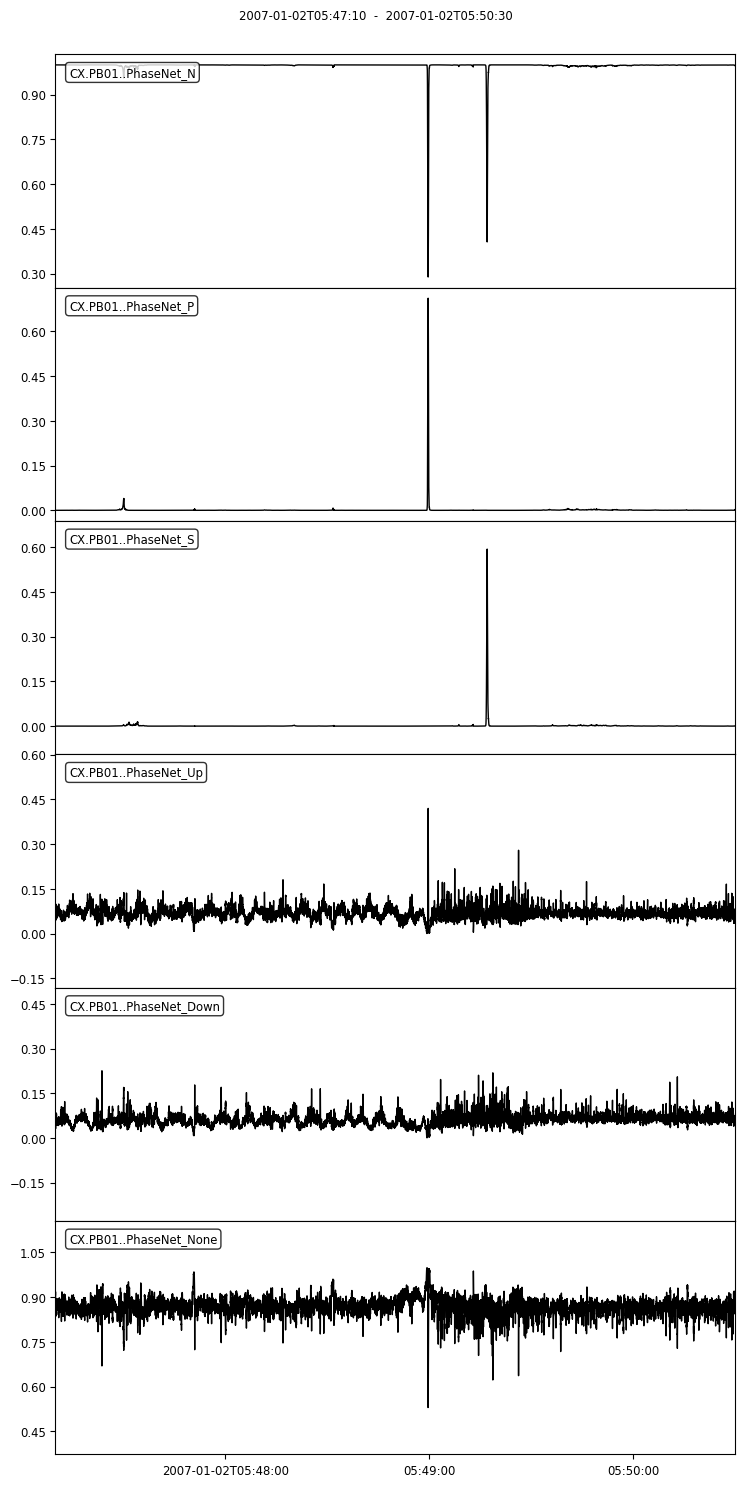

In [9]:
ann.plot()